<a href="https://colab.research.google.com/github/ZiyanNifail/Learning-Machine-Learning-Project/blob/main/Machine_Learning_in_Predicting_AirBNB_Rental_Price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np

The Notebook seeks to help predict the rental price of the AirBnB based of several features where the targeted value is the price. The insights provided by your predictive model could benefit both AirBnB hosts and guests. Hosts can use the insights to set competitive prices for their listings, while guests can use the insights to find the best deals on rentals. Additionally, the insights could be used by real estate investors and city planners to gain a better understanding of the housing market and make more informed decisions.

It is not specified who the target audience is for the analysis you've been working on. It could be any person or organization that is interested in understanding the rental prices of AirBnBs based on various features. Some examples of potential target audiences could be: -AirBnB hosts looking to set competitive prices for their listings -AirBnB guests looking to find the best deals on rentals -Real estate investors and city planners looking to gain a better understanding of the housing market and make more informed decisions -Data scientists and researchers looking to explore and understand the relationship between AirBnB rental prices and various features.

In [54]:
df = pd.read_csv("/content/drive/MyDrive/(2) Tuesday 8:30pm - Ziyan/Workfile/dataSP23 (1).csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,1,Clinton Hill Apartment Single Bedroom ! Pratt ~~,30610258,Santiago,Brooklyn,Clinton Hill,40.69591,-73.96284,Private room,58,2,1,9/23/2018,0.10,1,0
1,2,Andy Phillips,6180052,Andrian,Brooklyn,Fort Greene,40.68769,-73.97490,Private room,99,5,4,9/29/2017,0.17,1,250
2,3,"Stylish, Comfortable, and Affordable in Brooklyn",5957027,Zachary,Brooklyn,Crown Heights,40.67667,-73.91750,Entire home/apt,180,2,126,6/14/2019,3.74,1,74
3,4,15 min train ride to Times Sq and US OPEN,101602599,M,Queens,Woodside,40.74340,-73.90588,Entire home/apt,50,1,95,6/24/2019,5.63,2,0
4,5,Sunny 2 bdrm Park Slope Apt w/ Yard 3min to Su...,106168581,Jason,Brooklyn,South Slope,40.66600,-73.99020,Entire home/apt,210,4,88,7/4/2019,4.41,1,20


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27379 entries, 0 to 27378
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              27379 non-null  int64  
 1   name                            27370 non-null  object 
 2   host_id                         27379 non-null  int64  
 3   host_name                       27369 non-null  object 
 4   neighbourhood_group             27379 non-null  object 
 5   neighbourhood                   27379 non-null  object 
 6   latitude                        27379 non-null  float64
 7   longitude                       27379 non-null  float64
 8   room_type                       27379 non-null  object 
 9   price                           27379 non-null  int64  
 10  minimum_nights                  27379 non-null  int64  
 11  number_of_reviews               27379 non-null  int64  
 12  last_review                     

In [55]:
df = df.drop(['id','name','host_id','host_name','neighbourhood','last_review','reviews_per_month','calculated_host_listings_count'], axis = 1)
df.head()

,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,availability_365
0,Brooklyn,40.69591,-73.96284,Private room,58,2,1,0
1,Brooklyn,40.68769,-73.97490,Private room,99,5,4,250
2,Brooklyn,40.67667,-73.91750,Entire home/apt,180,2,126,74
3,Queens,40.74340,-73.90588,Entire home/apt,50,1,95,0
4,Brooklyn,40.66600,-73.99020,Entire home/apt,210,4,88,20


In [56]:
df['total_price'] = df['price'] * df['minimum_nights']
df

,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,availability_365,total_price
0,Brooklyn,40.69591,-73.96284,Private room,58,2,1,0,116
1,Brooklyn,40.68769,-73.97490,Private room,99,5,4,250,495
2,Brooklyn,40.67667,-73.91750,Entire home/apt,180,2,126,74,360
3,Queens,40.74340,-73.90588,Entire home/apt,50,1,95,0,50
4,Brooklyn,40.66600,-73.99020,Entire home/apt,210,4,88,20,840
...,...,...,...,...,...,...,...,...,...
27374,Manhattan,40.74735,-73.99974,Entire home/apt,585,3,7,0,1755
27375,Bronx,40.84499,-73.91157,Entire home/apt,60,5,3,0,300
27376,Brooklyn,40.63981,-73.90211,Entire home/apt,80,3,15,365,240
27377,Manhattan,40.73212,-73.98247,Private room,150,2,10,36,300


In [57]:
df = df.drop(['price','minimum_nights'], axis = 1)

In [9]:
df.head(3)

,neighbourhood_group,latitude,longitude,room_type,number_of_reviews,availability_365,total_price
0,Brooklyn,40.69591,-73.96284,Private room,1,0,116
1,Brooklyn,40.68769,-73.97490,Private room,4,250,495
2,Brooklyn,40.67667,-73.91750,Entire home/apt,126,74,360


# Checking for missing value
- isnull().sum()

In [10]:
# Checking for missing values
df.isnull().sum()

,0
neighbourhood_group,0
latitude,0
longitude,0
room_type,0
number_of_reviews,0
availability_365,0
total_price,0


# Check for Outliers

In [16]:
def check_outliers(df, col):
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - (1.5 * iqr)
  upper_bound = q3 + (1.5 * iqr)

  return df[(df[col] < lower_bound) | (df[col] > upper_bound)]

In [17]:
df['total_price'].dtype

dtype('int64')

In [18]:
check_outliers(df,'total_price')

,neighbourhood_group,latitude,longitude,room_type,number_of_reviews,availability_365,total_price
7,Brooklyn,40.67625,-73.97038,Entire home/apt,1,365,4980
17,Manhattan,40.75403,-73.96714,Entire home/apt,0,250,19992
23,Manhattan,40.75880,-73.96611,Entire home/apt,1,341,7800
26,Brooklyn,40.70653,-73.94620,Entire home/apt,45,244,3780
35,Manhattan,40.73722,-74.00263,Entire home/apt,15,54,4500
...,...,...,...,...,...,...,...
27348,Brooklyn,40.68907,-73.95217,Private room,13,333,1950
27355,Manhattan,40.74775,-73.99167,Entire home/apt,1,0,1998
27371,Manhattan,40.76344,-73.99290,Entire home/apt,4,307,4260
27372,Manhattan,40.72167,-73.99075,Private room,2,0,2550


# LabelEncoding
- Convert categorical/text data into binary/numerical

In [19]:
from sklearn.preprocessing import LabelEncoder

In [20]:
le = LabelEncoder()

df['neighbourhood_group'] = le.fit_transform(df['neighbourhood_group'])
df['room_type'] = le.fit_transform(df['room_type'])

df.head(5)

,neighbourhood_group,latitude,longitude,room_type,number_of_reviews,availability_365,total_price
0,1,40.69591,-73.96284,1,1,0,116
1,1,40.68769,-73.97490,1,4,250,495
2,1,40.67667,-73.91750,0,126,74,360
3,3,40.74340,-73.90588,0,95,0,50
4,1,40.66600,-73.99020,0,88,20,840


# Splitting the data into Training and Testing
- train_test_split() >> X_train, X_test, y_train, y_test

In [53]:
X = df.drop('total_price', axis = 1) # Features
y = df['total_price'] # Label

In [28]:
from sklearn.model_selection import train_test_split, cross_val_score

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

# Scaling

In [23]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.fit_transform(X_test)

In [24]:
X_train

array([[ 0.44178127, -0.14553225, -0.61285077, -0.92291504, -0.4121999 ,
         0.20534517],
       [ 0.44178127,  1.14987236, -0.32618667, -0.92291504, -0.50148715,
        -0.83494317],
       [ 0.44178127,  0.22808933, -0.92248266, -0.92291504, -0.50148715,
         1.5949274 ],
       ...,
       [-0.92223553, -0.75687971,  0.43413407,  0.91394167, -0.50148715,
         1.71642093],
       [-0.92223553, -1.04240717,  0.1996892 , -0.92291504, -0.2336254 ,
        -0.8577232 ],
       [-0.92223553, -0.75101897,  0.11171821, -0.92291504,  5.52540237,
        -0.37174909]])

# Training Model

In [25]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

# Making Prediction

In [26]:
y_pred = model.predict(X_test)
y_pred

array([2452.43178855, -251.27587264,  276.38162712, ..., 1294.32878663,
       3386.98009764, 2557.6221001 ])

# Accuracy Of the model

In [29]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X = sc.fit_transform(X)


In [27]:
from sklearn.metrics import r2_score

print(f"R2 Score: {r2_score(y_pred, y_test)}")

R2 Score: -18.064135970495663


In [31]:
score1 = cross_val_score(model, X,y, cv = 5)

print(f'Cross Validation Score: {score1}')
print(f'Cross Validation Score: {score1.mean()}')

Cross Validation Score: [0.02759263 0.02143062 0.03764318 0.02858137 0.04588217]
Cross Validation Score: 0.032225993885149906


In [33]:
from sklearn.model_selection import KFold
kfold = KFold(n_splits = 5, shuffle =True, random_state = 42)

In [34]:
score1 = cross_val_score(model, X,y, cv = kfold)

print(f'Cross Validation Score: {score1}')
print(f'Cross Validation Score: {score1.mean()}')

Cross Validation Score: [0.05035988 0.04673115 0.05096166 0.014609   0.01864726]
Cross Validation Score: 0.03626179029587244


# Visualising the Data

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='total_price'>

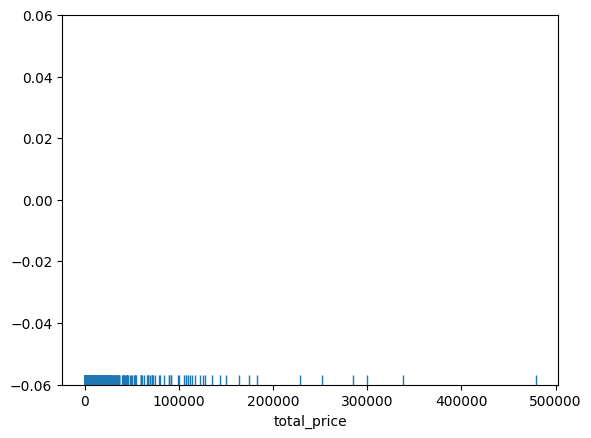

In [45]:
sns.rugplot(df['total_price'])

In [47]:
df['total_price'].describe()

,total_price
count,27379.000000
mean,1208.402023
std,6698.556766
min,0.000000
25%,135.000000
50%,300.000000
75%,736.500000
max,478800.000000


In [49]:
df['total_price'].idxmax()

5577

In [50]:
df.iloc[5577]

,5577
neighbourhood_group,1.00000
latitude,40.68807
longitude,-73.95426
room_type,1.00000
number_of_reviews,0.00000
availability_365,347.00000
total_price,478800.00000


<Axes: xlabel='neighbourhood_group', ylabel='total_price'>

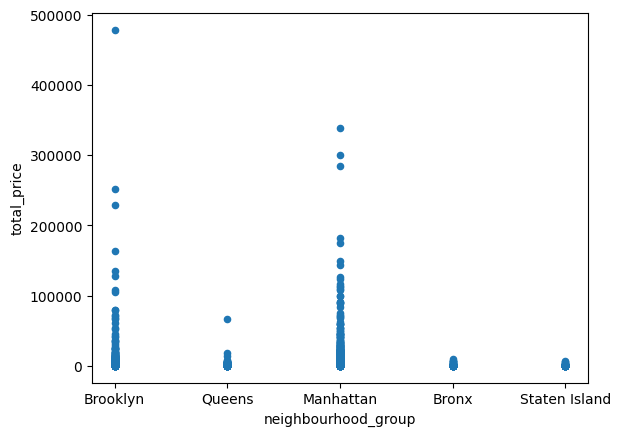

In [58]:
df.plot(kind = 'scatter', x='neighbourhood_group', y='total_price')

<Axes: xlabel='room_type', ylabel='total_price'>

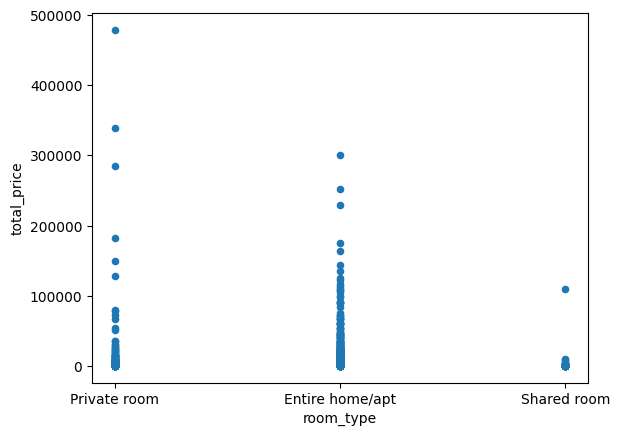

In [59]:
df.plot(kind = 'scatter', x='room_type', y='total_price')